In [3]:
import zipfile
import os

def unzip_folder(zip_file_path, extract_to):
    """
    Unzips a zip file to the specified directory.

    :param zip_file_path: Path to the zip file
    :param extract_to: Directory where files should be extracted
    """
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
        print(f"Extracted all files to: {extract_to}")

# Example usage
zip_file_path = '/content/test.zip'  # Replace with your zip file path
extract_to = '/content/test1'   # Replace with your desired extraction path

unzip_folder(zip_file_path, extract_to)


Extracted all files to: /content/test1


In [8]:
import os
import shutil
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the trained model
model = load_model('/content/Final_model.h5')

# Directory paths
test_images_dir = '/content/test1/test'  # Replace with your test dataset path
misclassified_dir = '/content/misclassified_images2'

# Create a folder for misclassified images
if not os.path.exists(misclassified_dir):
    os.makedirs(misclassified_dir)

# Class label mapping (update this list to match your class order in training)
class_labels = ['Normal', 'laser scars', 'Stage1', 'Stage2', 'Stage3', 'Stage4']
label_to_index = {label: idx for idx, label in enumerate(class_labels)}

# Function to preprocess the image
def preprocess_image(image_path, target_size):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize if your model was trained with normalized images
    return img_array

# Collect all image paths and true labels
image_paths = []
true_labels = []

for label_dir in os.listdir(test_images_dir):
    class_dir = os.path.join(test_images_dir, label_dir)
    if os.path.isdir(class_dir):
        for image_file in os.listdir(class_dir):
            image_paths.append(os.path.join(class_dir, image_file))
            true_labels.append(label_to_index[label_dir])  # Map class name to numeric index

# Iterate through the test images and find misclassified ones
for idx, image_path in enumerate(image_paths):
    true_label = true_labels[idx]  # True label for the image
    img_array = preprocess_image(image_path, target_size=(299, 299))  # Replace with your model's input size
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction[0])

    # Check if the prediction is incorrect
    if predicted_class != true_label:
        # Save the misclassified image to the folder
        image_name = os.path.basename(image_path)
        shutil.copy(image_path, os.path.join(misclassified_dir, image_name))
        print(f"Misclassified: {image_name} | Predicted: {class_labels[predicted_class]}, Actual: {class_labels[true_label]}")

print(f"All misclassified images are saved to: {misclassified_dir}")


Misclassified: Normal_140_aug_759.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_201_aug_381.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_122_aug_430.png | Predicted: Stage1, Actual: Normal
Misclassified: Normal_95_aug_425.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_154_aug_502.png | Predicted: Stage2, Actual: Normal
Misclassified: Normal_209_aug_250.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_202_aug_516.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_95_aug_479.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_95_aug_827.png | Predicted: Stage3, Actual: Normal
Misclassified: Normal_227_aug_472.png | Predicted: Stage2, Actual: Normal
Misclassified: Normal_209_aug_248.png | Predicted: Stage3, Actual: Normal
Misclassified: laser_scars_24_aug_415.png | Predicted: Stage3, Actual: laser scars
Misclassified: laser_scars_102_aug_803.png | Predicted: Stage2, Actual: laser scars
Misclassified: laser_s

In [9]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No convolutional layer found in the model.")


In [10]:
import tensorflow as tf  # Import TensorFlow at the beginning of the file

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No convolutional layer found in the model.")

# Find and print the name of the last convolutional layer
last_conv_layer_name = find_last_conv_layer(model)
print(f"Last convolutional layer: {last_conv_layer_name}")

Last convolutional layer: conv5_block16_2_conv


In [11]:
import os

# Specify the folder path
folder_path = '/content/misclassified_images2'

# Count the number of images in the folder
image_count = len([file for file in os.listdir(folder_path) if file.endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])

print(f"Number of images in the folder '{folder_path}': {image_count}")


Number of images in the folder '/content/misclassified_images2': 49


In [14]:
# Dictionary to store the count of images per class
class_image_count = {}

# Supported image file extensions
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')

# Loop through each subfolder (class) in the main directory
for class_folder in os.listdir(test_images_dir):
    class_path = os.path.join(test_images_dir, class_folder)
    if os.path.isdir(class_path):  # Check if it's a folder
        image_count = len([file for file in os.listdir(class_path) if file.endswith(image_extensions)])
        class_image_count[class_folder] = image_count

# Print the count of images per class
for class_name, count in class_image_count.items():
    print(f"Class '{class_name}': {count} images")

Class 'Normal': 67 images
Class 'laser scars': 56 images
Class 'Stage3': 64 images
Class 'Stage2': 74 images
Class 'Stage1': 81 images


In [15]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Function to preprocess and resize an image
def preprocess_and_resize_image(image_path, target_size=(299, 299)):
    try:
        # Load the image and resize
        img = load_img(image_path, target_size=target_size)  # Resize to 299x299
        img_array = img_to_array(img)  # Convert to NumPy array
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        img_array /= 255.0  # Normalize pixel values to range [0, 1]
        return img_array
    except Exception as e:
        print(f"Error processing the image: {e}")
        return None

# Example usage
image_path = "/content/misclassified_images2/Stage_2_ROP_128_aug_337.png"  # Replace with your image path
preprocessed_image = preprocess_and_resize_image(image_path, target_size=(299, 299))

if preprocessed_image is not None:
    print(f"Preprocessed image shape: {preprocessed_image.shape}")


Preprocessed image shape: (1, 299, 299, 3)


In [16]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b76043d2a80e13350dbaf1c3655288c251c0ccab8493a41fcbdc2c049b732dfc
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: 2


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

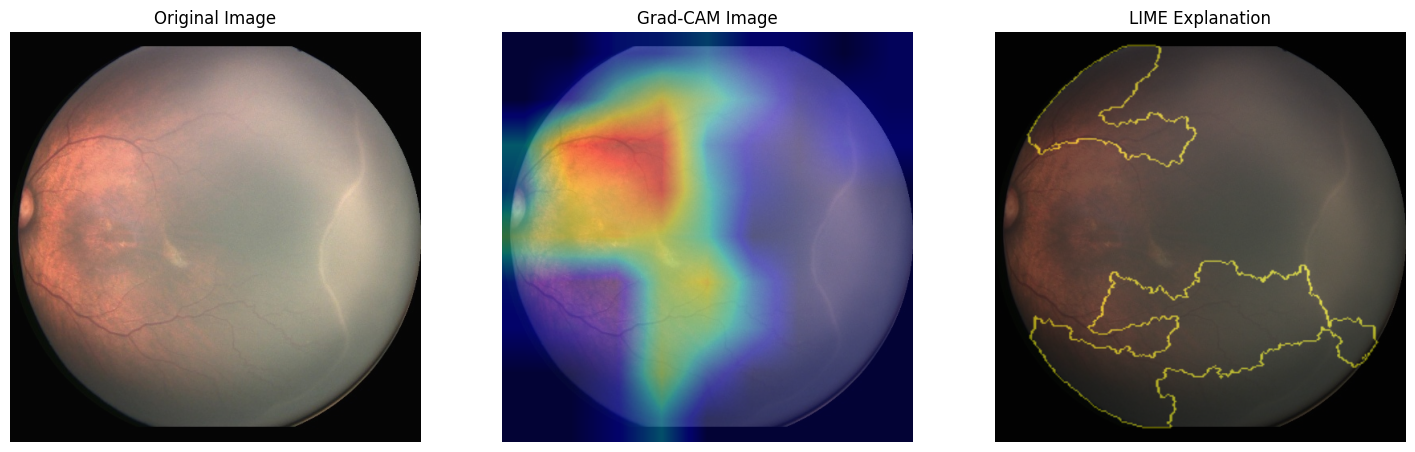

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Load your trained model
#model = load_model('/content/rop_model.h5')

# Function to preprocess the image
def preprocess_image(image_path, target_size):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming your model was trained with normalized images
    return img_array

# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Compute the guided gradients and their average
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Multiply the activations with the pooled gradients
    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

# Function to display the original image, Grad-CAM, and LIME explanation together
def display_all_explanations(image_path, heatmap, lime_image, alpha=0.4):
    img = load_img(image_path)
    img = np.array(img)

    # Resize heatmap to match image size for Grad-CAM
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)  # Remove the channel dimension

    # Apply colormap to heatmap for Grad-CAM
    heatmap = np.uint8(255 * heatmap)
    heatmap = plt.cm.jet(heatmap)[:, :, :3]  # Keep RGB channels only
    heatmap = np.uint8(heatmap * 255)  # Scale heatmap to [0, 255]

    # Superimpose heatmap on image
    superimposed_img = img * (1 - alpha) + heatmap * alpha

    # Resize the LIME explanation for the original image size
    lime_image_resized = tf.image.resize(lime_image, (img.shape[0], img.shape[1])).numpy()

    # Plot the images
    plt.figure(figsize=(18, 6))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img.astype('uint8'))
    plt.title("Original Image")
    plt.axis('off')

    # Grad-CAM image
    plt.subplot(1, 3, 2)
    plt.imshow(superimposed_img.astype('uint8'))
    plt.title("Grad-CAM Image")
    plt.axis('off')

    # LIME explanation on original image
    plt.subplot(1, 3, 3)
    plt.imshow(img.astype('uint8'))
    plt.imshow(lime_image_resized, alpha=0.5)  # Overlay LIME explanation
    plt.title("LIME Explanation")
    plt.axis('off')

    plt.show()

# Function to apply LIME
def explain_with_lime(image_path, model, target_size=(299, 299)):
    # Preprocess image for LIME
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize image for model

    # Define the explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the image prediction
    explanation = explainer.explain_instance(
        img_array[0], model.predict, top_labels=5, hide_color=0, num_samples=1000
    )

    # Get the explanation for the top predicted class
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )

    # Mark boundaries on the image to highlight important features
    marked_image = mark_boundaries(temp / 255.0, mask)

    return marked_image

# Path to a misclassified image
image_path = '/content/misclassified_images2/Stage_2_ROP_60_aug_756.png'

# Preprocess the image for Grad-CAM
img_array = preprocess_image(image_path, target_size=(299, 299))

# Predict the class
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])
print(f"Predicted class: {predicted_class}")

last_conv_layer_name = "conv5_block16_2_conv"
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Apply LIME explanation
lime_image = explain_with_lime(image_path, model)

# Display the original image, Grad-CAM, and LIME explanation
display_all_explanations(image_path, heatmap, lime_image)


In [20]:
pip install shap

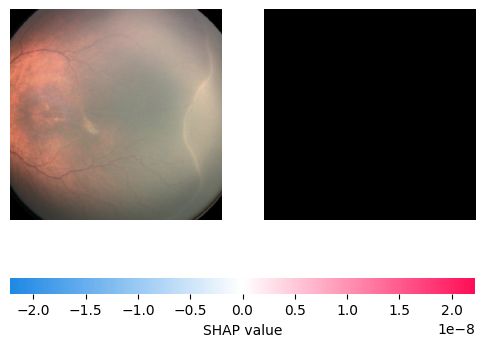

In [26]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Load your trained model
# model = load_model('/content/rop_model.h5')

# SHAP explainer function
def explain_with_shap(model, img_array, background_data):
    # Create an explainer using a background dataset
    explainer = shap.GradientExplainer(model, background_data)

    # Explain the prediction for the given image
    shap_values = explainer.shap_values(img_array)

    return shap_values

# Preprocess image for SHAP
image_path = '/content/misclassified_images2/Stage_2_ROP_60_aug_755.png'
img_array = preprocess_image(image_path, target_size=(299, 299))
background_data = background_data / 255.0

# Generate a background dataset for SHAP (random samples from training data or similar distribution)
# For example, use 50 random images from the training dataset
background_image_paths = [os.path.join('/content/test1/test/Stage2', img) for img in os.listdir('/content/test1/test/Stage2')]
  # Replace with actual data for better results

# Explain the prediction with SHAP
shap_values = explain_with_shap(model, img_array, background_data)

# Visualize the explanation for the top class
shap.image_plot(shap_values, img_array)
